In [1]:
# 0) IMPORTS
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms as T
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import random
import time

In [2]:
# 1) DATA PREPARATION

# Define paths
DATA_DIR = 'Dataset'
ANNOTATIONS_DIR = os.path.join(DATA_DIR, 'annotations')
IMAGES_DIR = os.path.join(DATA_DIR, 'images')

# Define class mapping
class_dict = {'helmet': 1, 'head': 2}
idx_to_class = {v: k for k, v in class_dict.items()}

# Function to parse XML annotation files
def parse_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # Get image size
    size = root.find('size')
    width = int(size.find('width').text)
    height = int(size.find('height').text)
    
    # Get all objects (bounding boxes)
    boxes = []
    labels = []
    
    for obj in root.findall('object'):
        label = obj.find('name').text
        if label not in class_dict:
            continue
            
        # Get bounding box coordinates
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        
        # Store as [x_min, y_min, x_max, y_max]
        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(class_dict[label])
    
    # Convert to numpy arrays
    boxes = np.array(boxes, dtype=np.float32)
    labels = np.array(labels, dtype=np.int64)
    
    return {
        'boxes': boxes,
        'labels': labels,
        'width': width,
        'height': height
    }

# Get all annotation files
all_xml_files = [os.path.join(ANNOTATIONS_DIR, f) for f in os.listdir(ANNOTATIONS_DIR) if f.endswith('.xml')]
print(f"Total annotation files: {len(all_xml_files)}")

# Create a dataset dictionary
dataset_dict = []
for xml_file in all_xml_files:
    filename = os.path.basename(xml_file).replace('.xml', '.png')
    img_path = os.path.join(IMAGES_DIR, filename)
    
    if os.path.exists(img_path):
        annotation = parse_annotation(xml_file)
        
        # Skip images with no valid annotations
        if len(annotation['boxes']) == 0:
            continue
            
        dataset_dict.append({
            'img_path': img_path,
            'annotation': annotation,
            'file_name': filename
        })

print(f"Total valid images: {len(dataset_dict)}")

# Split dataset into train, validation, and test sets
train_val_data, test_data = train_test_split(dataset_dict, test_size=0.2, random_state=42)
train_data, val_data = train_test_split(train_val_data, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

print(f"Train set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")
print(f"Test set size: {len(test_data)}")

# Calculate class distribution
def calculate_class_distribution(data_list):
    class_counts = {k: 0 for k in class_dict.keys()}
    for data in data_list:
        annotation = data['annotation']
        labels = annotation['labels']
        for label_idx in labels:
            class_name = idx_to_class[label_idx]
            class_counts[class_name] += 1
    return class_counts

train_dist = calculate_class_distribution(train_data)
val_dist = calculate_class_distribution(val_data)
test_dist = calculate_class_distribution(test_data)

print("Class distribution:")
print(f"Train: {train_dist}")
print(f"Validation: {val_dist}")
print(f"Test: {test_dist}")

# Custom dataset class
class HelmetDataset(Dataset):
    def __init__(self, dataset_dicts, transforms=None):
        self.dataset_dicts = dataset_dicts
        self.transforms = transforms
        
    def __len__(self):
        return len(self.dataset_dicts)
    
    def __getitem__(self, idx):
        dataset_dict = self.dataset_dicts[idx]
        
        # Load image
        img_path = dataset_dict['img_path']
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Get annotations
        annotation = dataset_dict['annotation']
        boxes = annotation['boxes'].copy()
        labels = annotation['labels'].copy()
        
        # Apply transformations
        if self.transforms:
            transformed = self.transforms(image=image, bboxes=boxes, labels=labels)
            image = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['labels']
            
            # Convert boxes to tensor format
            if len(boxes) > 0:
                boxes = torch.as_tensor(boxes, dtype=torch.float32)
            else:
                boxes = torch.zeros((0, 4), dtype=torch.float32)
            
            labels = torch.as_tensor(labels, dtype=torch.int64)
        else:
            # Convert to tensor without transforms
            image = torch.as_tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # Create target dictionary
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx])
        }
        
        return image, target

# Define transformations for training and validation
def get_train_transform():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Resize(height=416, width=416, p=1.0),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(p=1.0)
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

def get_valid_transform():
    return A.Compose([
        A.Resize(height=416, width=416, p=1.0),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(p=1.0)
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

# Create datasets
train_dataset = HelmetDataset(train_data, transforms=get_train_transform())
val_dataset = HelmetDataset(val_data, transforms=get_valid_transform())
test_dataset = HelmetDataset(test_data, transforms=get_valid_transform())

# Create data loaders
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

Total annotation files: 5000
Total valid images: 5000
Train set size: 3000
Validation set size: 1000
Test set size: 1000
Class distribution:
Train: {'helmet': 11532, 'head': 3555}
Validation: {'helmet': 3775, 'head': 954}
Test: {'helmet': 3659, 'head': 1276}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Visualizing samples from training set:


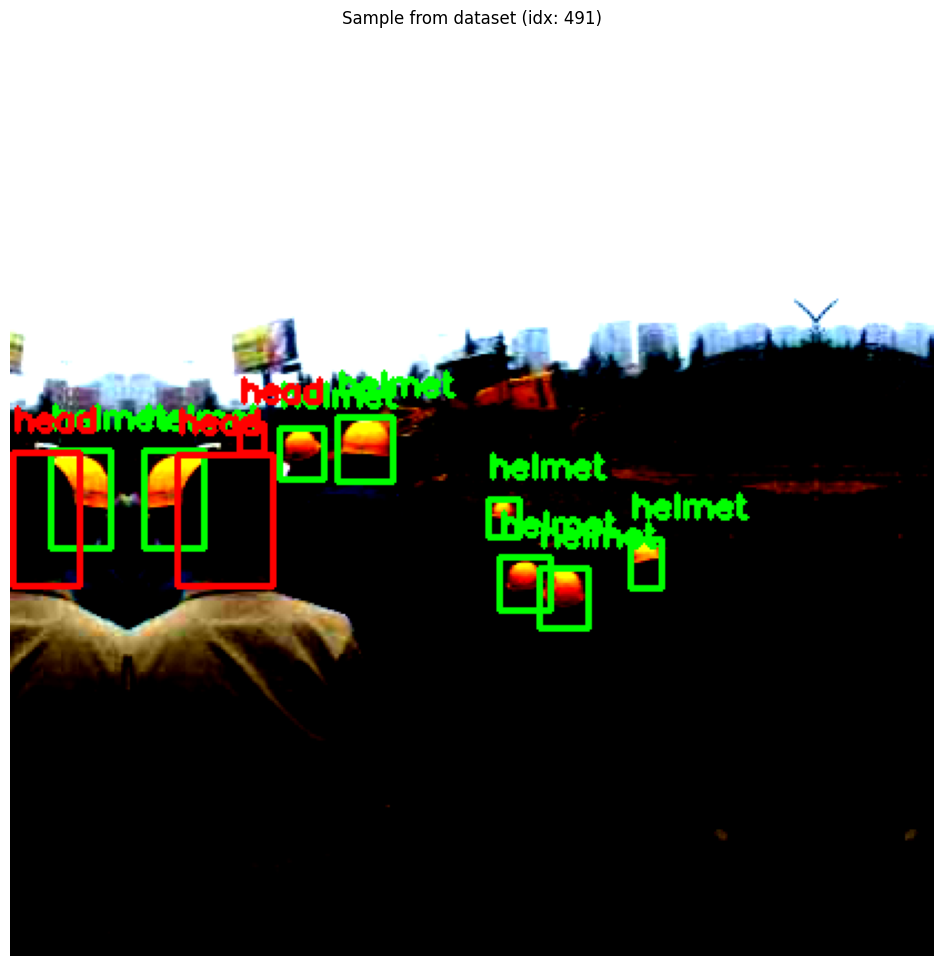

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


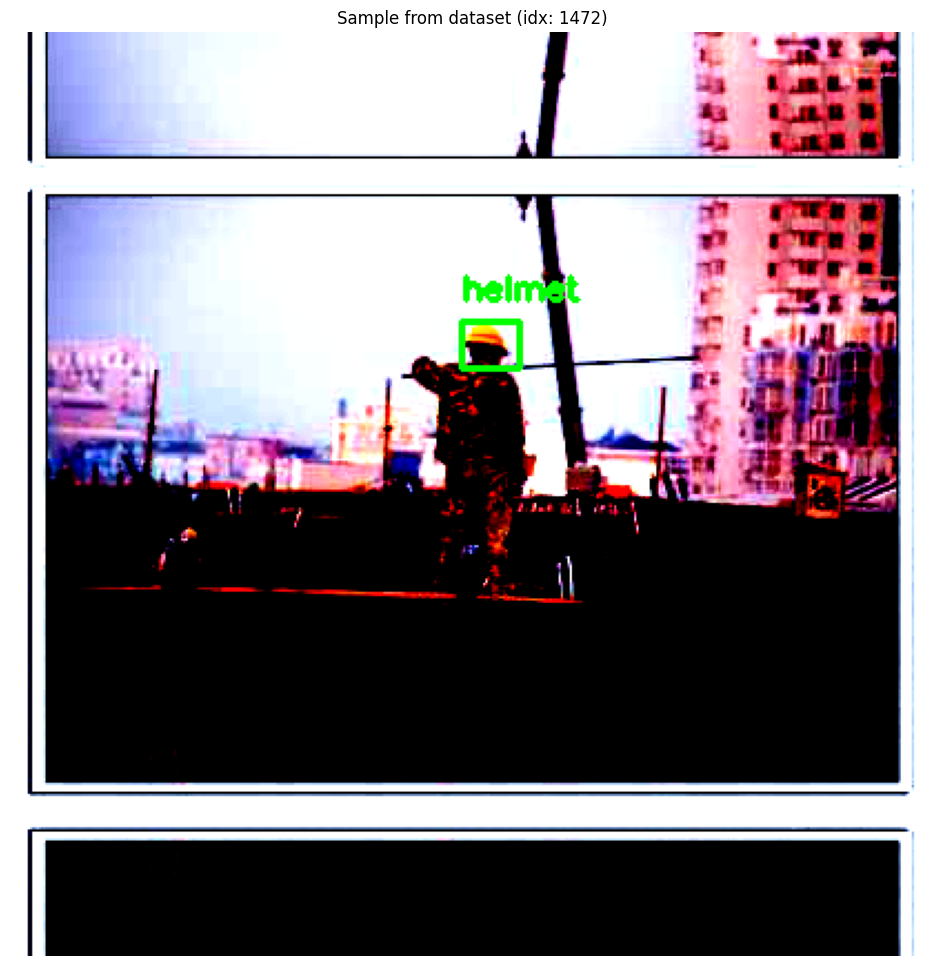

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


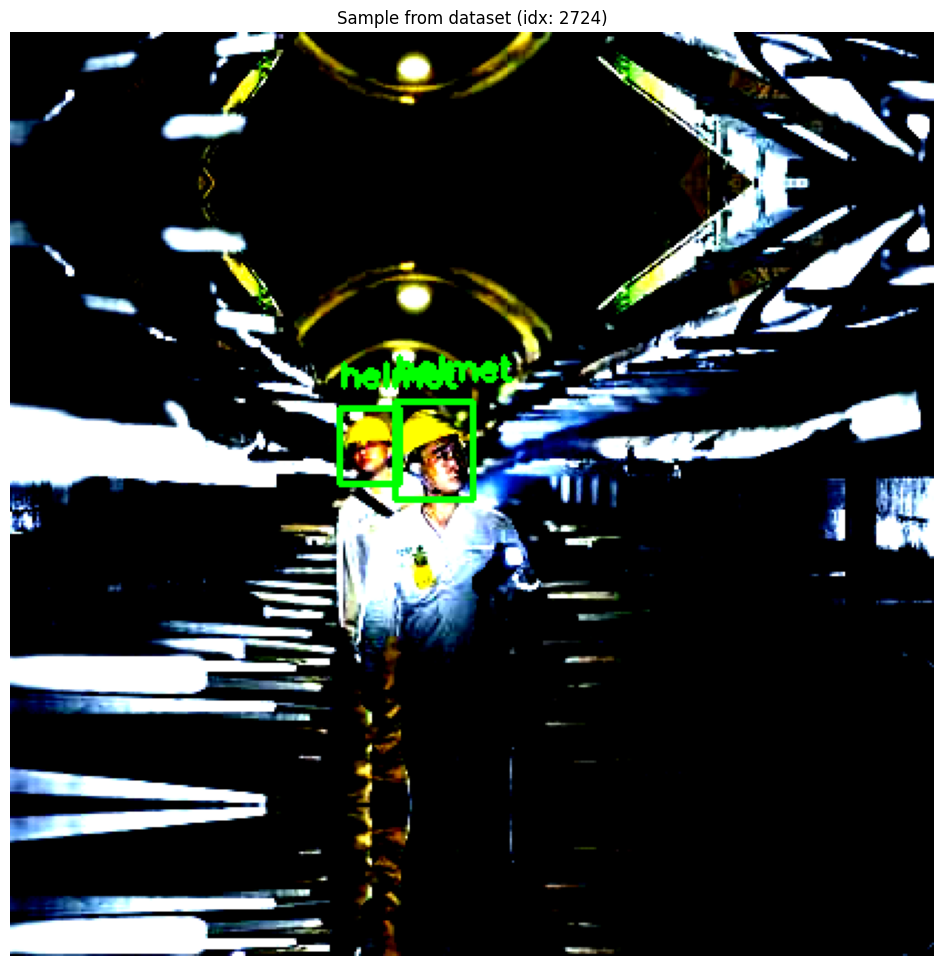

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Visualizing samples from validation set:


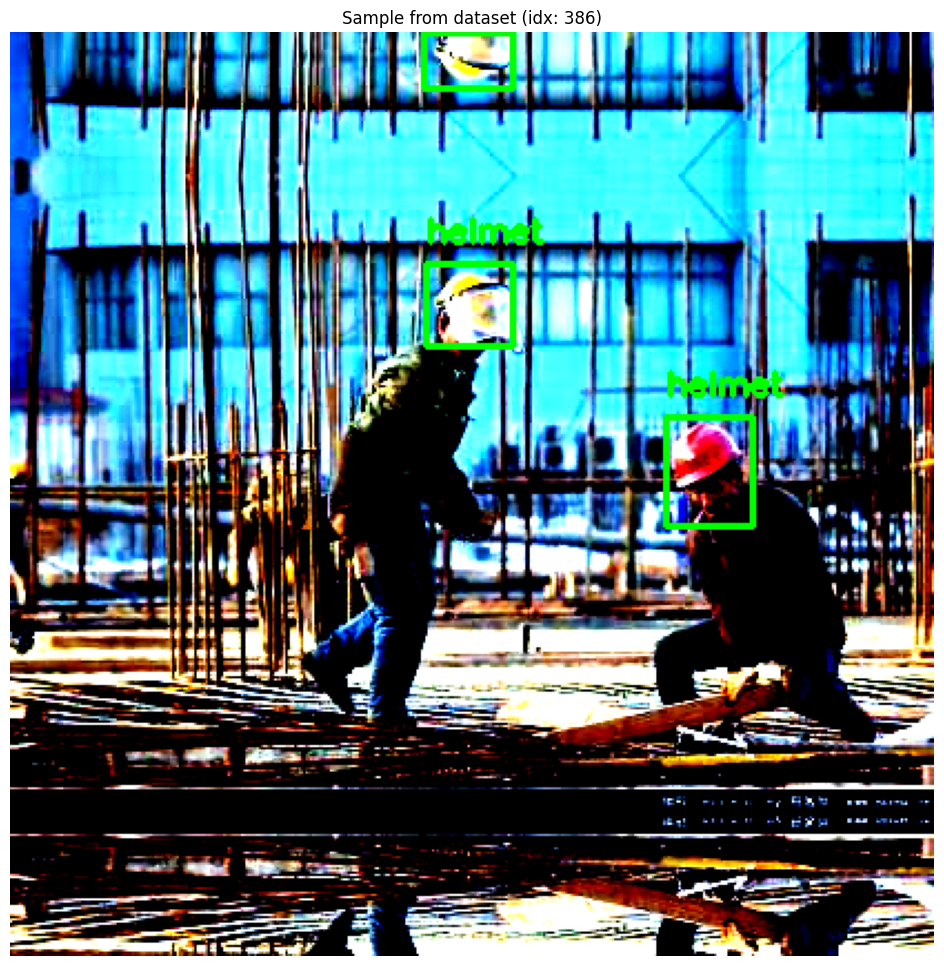

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


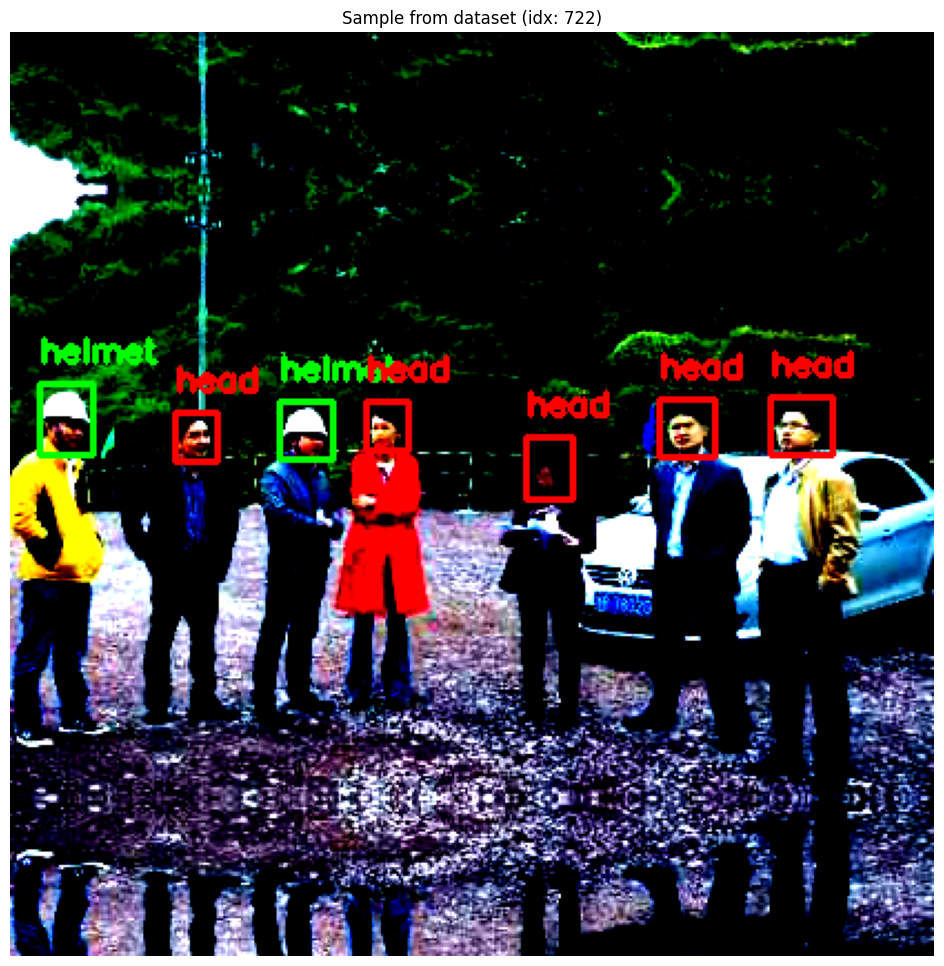

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Visualizing samples from test set:


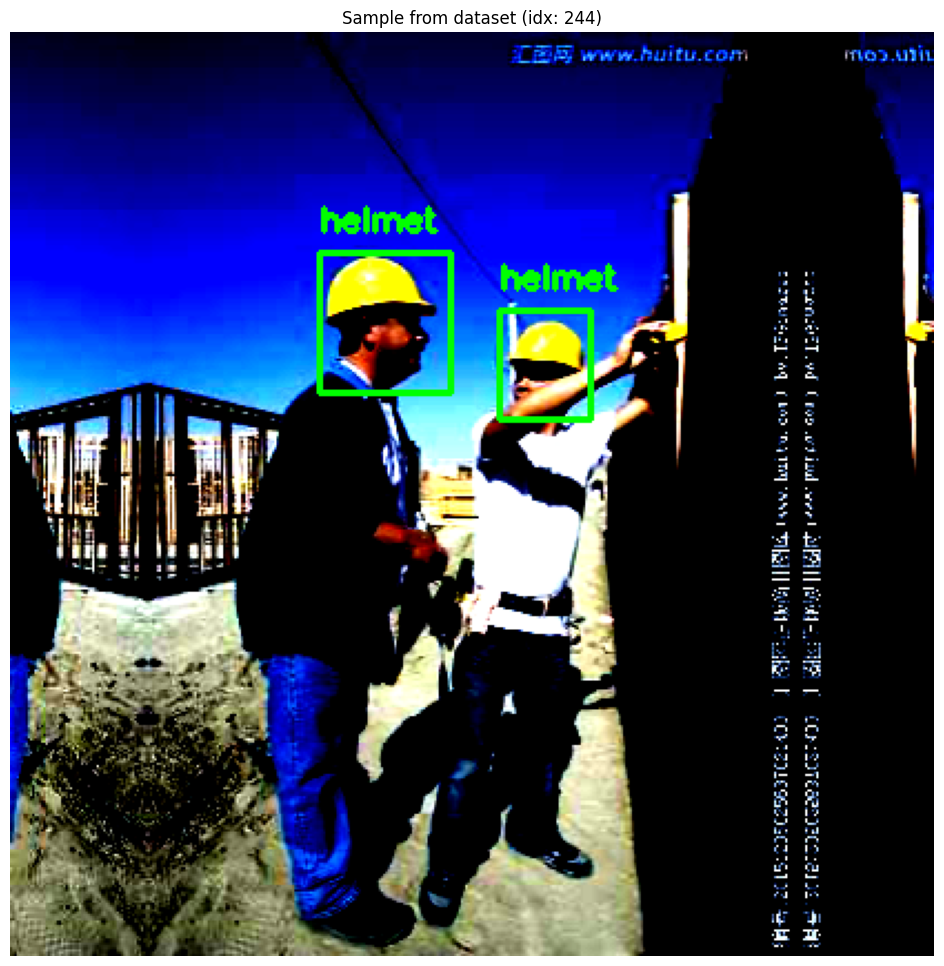

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


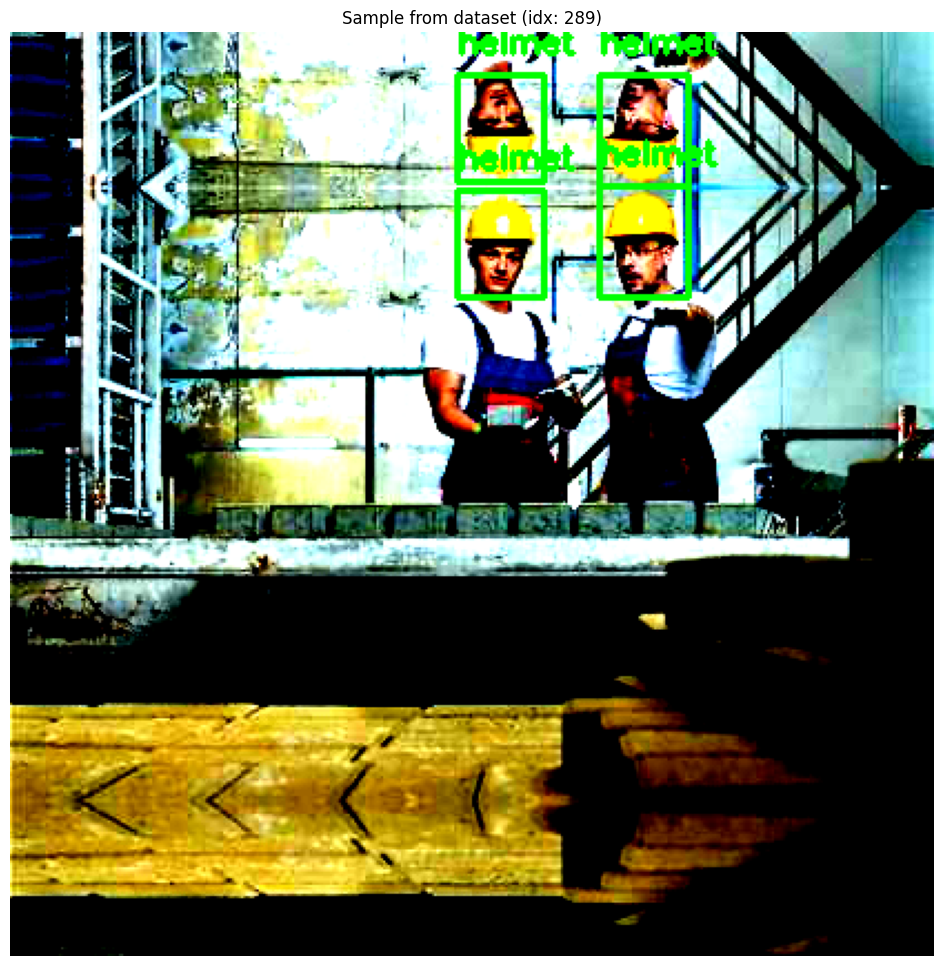

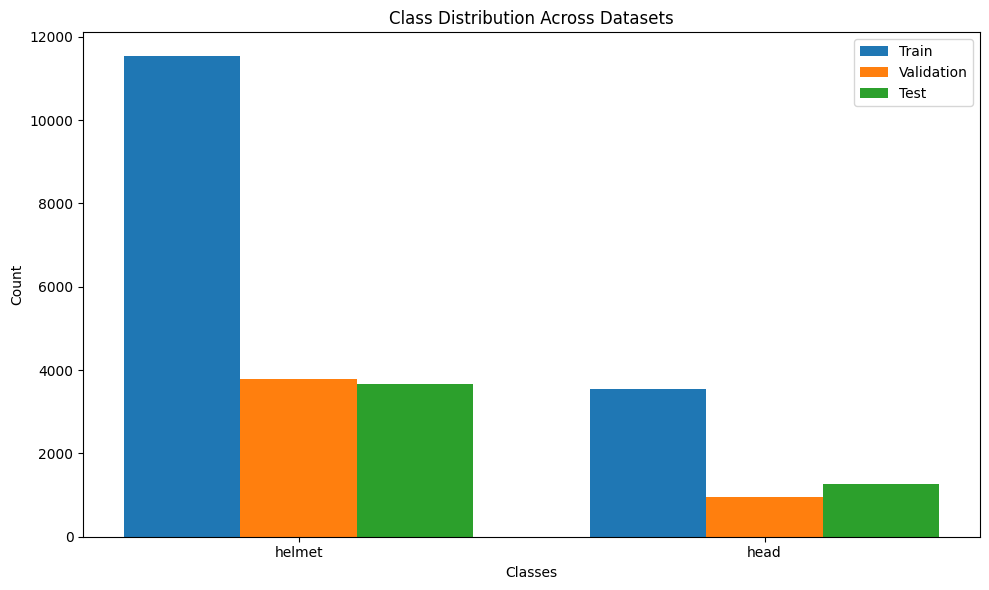

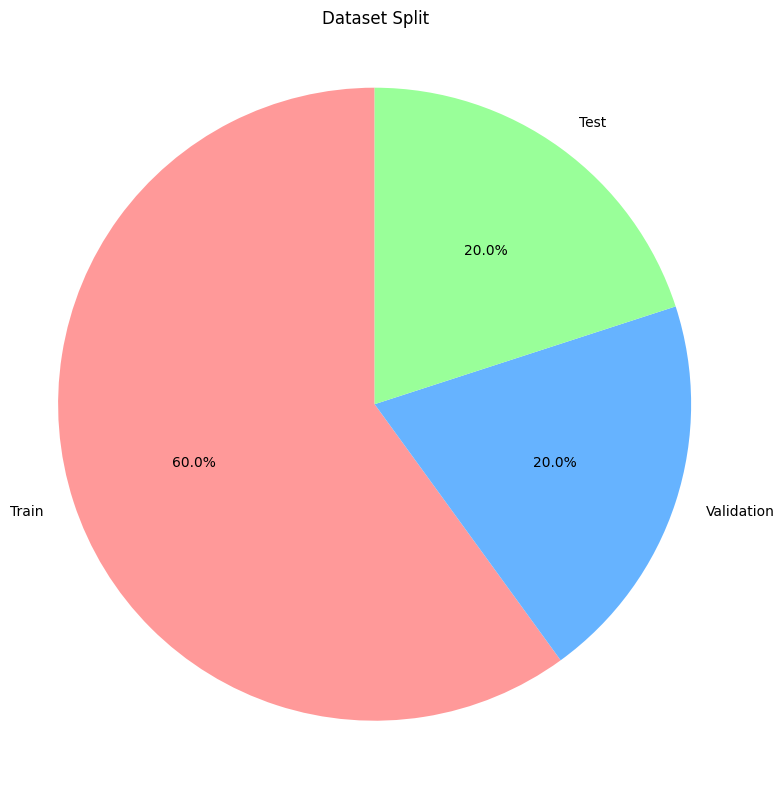

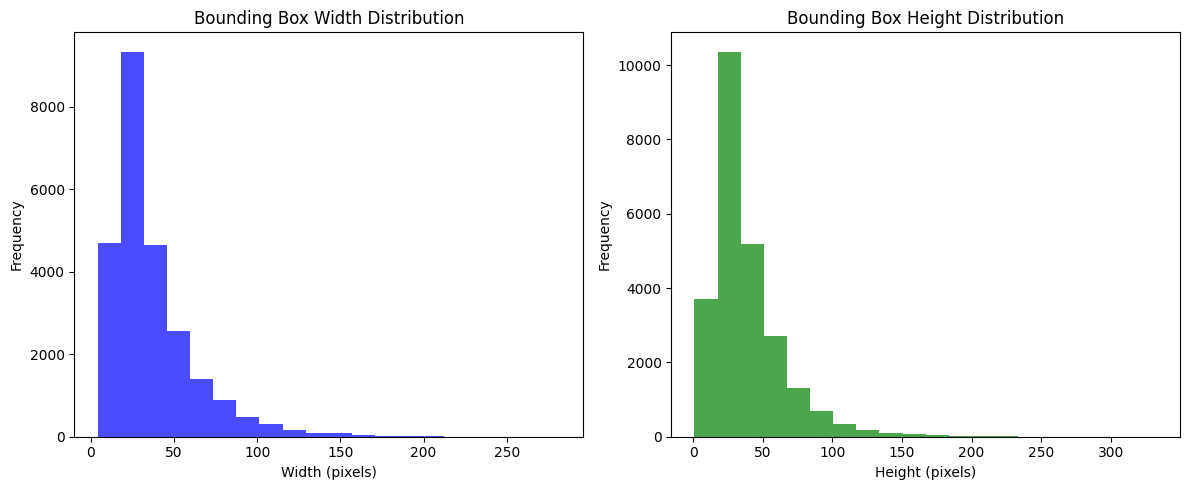

In [3]:
# 2) DATA VISUALIZATION

# Function to visualize images with bounding boxes
def visualize_sample(dataset, idx, figsize=(12, 12)):
    image, target = dataset[idx]
    
    # Convert tensor to numpy for visualization
    if isinstance(image, torch.Tensor):
        # De-normalize if needed
        if image.max() <= 1.0:
            image = image * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            image = image + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            image = image.clamp(0, 1)
        
        image = image.permute(1, 2, 0).cpu().numpy()
    
    # Get boxes and labels
    boxes = target['boxes'].cpu().numpy().astype(np.int32)
    labels = target['labels'].cpu().numpy()
    
    # Create a copy of the image for drawing
    image_with_boxes = image.copy()
    
    # Define colors for different classes
    colors = {
        1: (0, 255, 0),  # Green for helmet
        2: (255, 0, 0)   # Red for head (no helmet)
    }
    
    # Draw boxes
    for box, label in zip(boxes, labels):
        color = colors[label]
        cv2.rectangle(
            image_with_boxes,
            (box[0], box[1]),
            (box[2], box[3]),
            color,
            thickness=2
        )
        
        # Add label text
        class_name = idx_to_class[label]
        cv2.putText(
            image_with_boxes,
            class_name,
            (box[0], box[1] - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            thickness=2
        )
    
    # Display the image
    plt.figure(figsize=figsize)
    plt.imshow(image_with_boxes)
    plt.axis('off')
    plt.title(f'Sample from dataset (idx: {idx})')
    plt.show()

# Visualize some samples from each set
print("Visualizing samples from training set:")
for i in range(3):
    idx = random.randint(0, len(train_dataset) - 1)
    visualize_sample(train_dataset, idx)

print("Visualizing samples from validation set:")
for i in range(2):
    idx = random.randint(0, len(val_dataset) - 1)
    visualize_sample(val_dataset, idx)

print("Visualizing samples from test set:")
for i in range(2):
    idx = random.randint(0, len(test_dataset) - 1)
    visualize_sample(test_dataset, idx)

# Plot class distribution across datasets
def plot_class_distribution():
    classes = list(class_dict.keys())
    train_counts = [train_dist[cls] for cls in classes]
    val_counts = [val_dist[cls] for cls in classes]
    test_counts = [test_dist[cls] for cls in classes]
    
    x = np.arange(len(classes))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width, train_counts, width, label='Train')
    ax.bar(x, val_counts, width, label='Validation')
    ax.bar(x + width, test_counts, width, label='Test')
    
    ax.set_xlabel('Classes')
    ax.set_ylabel('Count')
    ax.set_title('Class Distribution Across Datasets')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

plot_class_distribution()

# Plot dataset split
def plot_dataset_split():
    labels = ['Train', 'Validation', 'Test']
    sizes = [len(train_data), len(val_data), len(test_data)]
    colors = ['#ff9999', '#66b3ff', '#99ff99']
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.axis('equal')
    plt.title('Dataset Split')
    plt.tight_layout()
    plt.show()

plot_dataset_split()

# Visualize bounding box statistics
def plot_bbox_statistics():
    # Collect width and height of bounding boxes
    widths = []
    heights = []
    
    for data in dataset_dict:
        annotation = data['annotation']
        boxes = annotation['boxes']
        
        for box in boxes:
            w = box[2] - box[0]
            h = box[3] - box[1]
            widths.append(w)
            heights.append(h)
    
    # Plot histograms
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.hist(widths, bins=20, color='blue', alpha=0.7)
    ax1.set_title('Bounding Box Width Distribution')
    ax1.set_xlabel('Width (pixels)')
    ax1.set_ylabel('Frequency')
    
    ax2.hist(heights, bins=20, color='green', alpha=0.7)
    ax2.set_title('Bounding Box Height Distribution')
    ax2.set_xlabel('Height (pixels)')
    ax2.set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

plot_bbox_statistics()

In [4]:
# 3) MODELLING

# Function to get the Faster R-CNN model
def get_faster_rcnn_model(num_classes):
    # Load pre-trained model
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
    
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    return model

# Initialize the model
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

num_classes = len(class_dict) + 1  # +1 for background class
model = get_faster_rcnn_model(num_classes)
model.to(device)

# Define optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Training and evaluation functions
def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    
    progress_bar = tqdm(dataloader, desc="Training")
    
    for images, targets in progress_bar:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Forward pass
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        total_loss += losses.item()
        progress_bar.set_postfix({"Loss": f"{losses.item():.4f}"})
    
    return total_loss / len(dataloader)

def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="Evaluating"):
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # Forward pass
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            total_loss += losses.item()
    
    return total_loss / len(dataloader)

# Training loop
num_epochs = 10
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    
    # Train one epoch
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    history['train_loss'].append(train_loss)
    
    # Evaluate
    val_loss = evaluate(model, val_loader, device)
    history['val_loss'].append(val_loss)
    
    # Update learning rate
    lr_scheduler.step()
    
    print(f"Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_faster_rcnn_model.pth')
        print("Saved best model!")
    
    print("-" * 50)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('training_history.png')
plt.show()

# Load the best model
model.load_state_dict(torch.load('best_faster_rcnn_model.pth'))
print("Loaded best model for testing!")

Using device: cpu


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\Giray/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


  0%|          | 0.00/160M [00:00<?, ?B/s]

Epoch 1/10


Training:   0%|          | 0/750 [00:00<?, ?it/s]

BrokenPipeError: [Errno 32] Broken pipe

In [ ]:
# 4) TESTING

# Function to calculate IoU
def calculate_iou(box1, box2):
    # Box format: [x1, y1, x2, y2]
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2
    
    # Calculate intersection area
    x1_i = max(x1_1, x1_2)
    y1_i = max(y1_1, y1_2)
    x2_i = min(x2_1, x2_2)
    y2_i = min(y2_1, y2_2)
    
    if x2_i < x1_i or y2_i < y1_i:
        return 0.0
    
    intersection_area = (x2_i - x1_i) * (y2_i - y1_i)
    
    # Calculate union area
    box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
    box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)
    union_area = box1_area + box2_area - intersection_area
    
    return intersection_area / union_area

# Function to calculate mAP
def calculate_map(predictions, targets, iou_threshold=0.5):
    all_detections = {}
    all_ground_truths = {}
    
    for class_id in range(1, len(class_dict) + 1):
        all_detections[class_id] = []
        all_ground_truths[class_id] = []
    
    # Collect all detections and ground truths
    for pred, target in zip(predictions, targets):
        pred_boxes = pred['boxes'].cpu().numpy()
        pred_scores = pred['scores'].cpu().numpy()
        pred_labels = pred['labels'].cpu().numpy()
        
        gt_boxes = target['boxes'].cpu().numpy()
        gt_labels = target['labels'].cpu().numpy()
        
        for class_id in range(1, len(class_dict) + 1):
            # Get detections for this class
            class_dets = [
                {'box': box, 'score': score}
                for box, score, label in zip(pred_boxes, pred_scores, pred_labels)
                if label == class_id
            ]
            all_detections[class_id].extend(class_dets)
            
            # Get ground truths for this class
            class_gts = [
                {'box': box, 'matched': False}
                for box, label in zip(gt_boxes, gt_labels)
                if label == class_id
            ]
            all_ground_truths[class_id].extend(class_gts)
    
    # Calculate AP for each class
    average_precisions = {}
    
    for class_id in range(1, len(class_dict) + 1):
        detections = all_detections[class_id]
        ground_truths = all_ground_truths[class_id]
        
        # Sort detections by score
        detections.sort(key=lambda x: x['score'], reverse=True)
        
        TP = np.zeros(len(detections))
        FP = np.zeros(len(detections))
        
        # Total number of ground truths
        total_gts = len(ground_truths)
        
        if total_gts == 0:
            average_precisions[class_id] = 0
            continue
        
        # Match detections to ground truths
        for i, detection in enumerate(detections):
            best_iou = 0
            best_gt_idx = -1
            
            for gt_idx, gt in enumerate(ground_truths):
                if gt['matched']:
                    continue
                
                iou = calculate_iou(detection['box'], gt['box'])
                
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx
            
            if best_iou >= iou_threshold:
                if not ground_truths[best_gt_idx]['matched']:
                    TP[i] = 1
                    ground_truths[best_gt_idx]['matched'] = True
                else:
                    FP[i] = 1
            else:
                FP[i] = 1
        
        # Compute cumulative sum
        cumsum_TP = np.cumsum(TP)
        cumsum_FP = np.cumsum(FP)
        
        # Calculate precision and recall
        precision = cumsum_TP / (cumsum_TP + cumsum_FP + 1e-10)
        recall = cumsum_TP / total_gts
        
        # Append sentinel values
        precision = np.concatenate(([0], precision, [0]))
        recall = np.concatenate(([0], recall, [1]))
        
        # Make precision monotonically decreasing
        for i in range(len(precision) - 1, 0, -1):
            precision[i - 1] = max(precision[i - 1], precision[i])
        
        # Find points where recall changes
        indices = np.where(recall[1:] != recall[:-1])[0] + 1
        
        # Sum precision at recall change points
        ap = np.sum((recall[indices] - recall[indices - 1]) * precision[indices])
        average_precisions[class_id] = ap
    
    mAP = sum(average_precisions.values()) / len(average_precisions)
    return mAP, average_precisions

# Function to run inference on test dataset
def test_model(model, dataloader, device):
    model.eval()
    predictions = []
    targets_list = []
    
    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="Testing"):
            images = list(image.to(device) for image in images)
            
            # Get predictions
            outputs = model(images)
            
            # Store predictions and targets
            predictions.extend(outputs)
            targets_list.extend(targets)
    
    return predictions, targets_list

# Run inference
print("Running inference on test set...")
model.eval()
predictions, targets = test_model(model, test_loader, device)

# Calculate mAP
print("Calculating mAP...")
mAP, class_APs = calculate_map(predictions, targets, iou_threshold=0.5)
print(f"mAP@0.5: {mAP:.4f}")

for class_id, ap in class_APs.items():
    class_name = idx_to_class[class_id]
    print(f"AP for {class_name}: {ap:.4f}")

# Visualize some test results
def visualize_predictions(model, dataset, idx, threshold=0.7, figsize=(12, 12)):
    model.eval()
    image, target = dataset[idx]
    
    # Convert to device
    image_tensor = image.unsqueeze(0).to(device)
    
    # Get prediction
    with torch.no_grad():
        prediction = model(image_tensor)[0]
    
    # Convert tensor to numpy for visualization
    image_np = image.permute(1, 2, 0).cpu().numpy()
    
    # De-normalize if needed
    if image_np.max() <= 1.0:
        image_np = image_np * np.array([0.229, 0.224, 0.225])
        image_np = image_np + np.array([0.485, 0.456, 0.406])
        image_np = np.clip(image_np, 0, 1)
    
    # Get boxes, scores, and labels
    boxes = prediction['boxes'].cpu().numpy().astype(np.int32)
    scores = prediction['scores'].cpu().numpy()
    labels = prediction['labels'].cpu().numpy()
    
    # Get ground truth
    gt_boxes = target['boxes'].cpu().numpy().astype(np.int32)
    gt_labels = target['labels'].cpu().numpy()
    
    # Create two copies of the image
    pred_image = image_np.copy()
    gt_image = image_np.copy()
    
    # Define colors for different classes
    colors = {
        1: (0, 255, 0),  # Green for helmet
        2: (255, 0, 0)   # Red for head (no helmet)
    }
    
    # Draw predicted boxes
    for box, score, label in zip(boxes, scores, labels):
        if score >= threshold:
            color = colors[label]
            cv2.rectangle(
                pred_image,
                (box[0], box[1]),
                (box[2], box[3]),
                color,
                thickness=2
            )
            
            # Add label and score text
            class_name = idx_to_class[label]
            text = f"{class_name}: {score:.2f}"
            cv2.putText(
                pred_image,
                text,
                (box[0], box[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                color,
                thickness=2
            )
    
    # Draw ground truth boxes
    for box, label in zip(gt_boxes, gt_labels):
        color = colors[label]
        cv2.rectangle(
            gt_image,
            (box[0], box[1]),
            (box[2], box[3]),
            color,
            thickness=2
        )
        
        # Add label text
        class_name = idx_to_class[label]
        cv2.putText(
            gt_image,
            class_name,
            (box[0], box[1] - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            thickness=2
        )
    
    # Display the images side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    ax1.imshow(gt_image)
    ax1.set_title('Ground Truth')
    ax1.axis('off')
    
    ax2.imshow(pred_image)
    ax2.set_title('Predictions (score > 0.7)')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize some test results
print("Visualizing test results:")
for i in range(5):
    idx = random.randint(0, len(test_dataset) - 1)
    visualize_predictions(model, test_dataset, idx)

# Function to detect helmets in a single image
def detect_helmets(model, image_path, threshold=0.7):
    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Apply transformations
    transform = get_valid_transform()
    transformed = transform(image=image)
    image_tensor = transformed['image']
    
    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0).to(device)
    
    # Run inference
    model.eval()
    with torch.no_grad():
        prediction = model(image_tensor)[0]
    
    # Get boxes, scores, and labels
    boxes = prediction['boxes'].cpu().numpy().astype(np.int32)
    scores = prediction['scores'].cpu().numpy()
    labels = prediction['labels'].cpu().numpy()
    
    # Filter by threshold
    mask = scores >= threshold
    boxes = boxes[mask]
    scores = scores[mask]
    labels = labels[mask]